In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/raghuvirkumawat/clean-data/SALES_DATA_CLEAN.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/raghuvirkumawat/clean-data/SALES_DATA_CLEAN.csv" ,sep=";")
df.head()


,SALES_DATE,STORE_ID,PRODUCT_ID,PRODUCT_CATEGORY,REGION,INVENTORY_LEVEL,UNITS_SOLD,UNITS_ORDERED,PRICE,DISCOUNT,WEATHER_CONDITION,PROMOTION,COMPETITOR_PRICING,SEASONALITY,EPIDEMIC,DEMAND
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [3]:
print( "Data Info:",df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   SALES_DATE          76000 non-null  object 
 1   STORE_ID            76000 non-null  object 
 2   PRODUCT_ID          76000 non-null  object 
 3   PRODUCT_CATEGORY    76000 non-null  object 
 4   REGION              76000 non-null  object 
 5   INVENTORY_LEVEL     76000 non-null  int64  
 6   UNITS_SOLD          76000 non-null  int64  
 7   UNITS_ORDERED       76000 non-null  int64  
 8   PRICE               76000 non-null  float64
 9   DISCOUNT            76000 non-null  int64  
 10  WEATHER_CONDITION   76000 non-null  object 
 11  PROMOTION           76000 non-null  int64  
 12  COMPETITOR_PRICING  76000 non-null  float64
 13  SEASONALITY         76000 non-null  object 
 14  EPIDEMIC            76000 non-null  int64  
 15  DEMAND              76000 non-null  int64  
dtypes: f

In [5]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# Assuming your DataFrame is named df
df['SALES_DATE'] = pd.to_datetime(df['SALES_DATE'])

# Aggregate daily demand per product
daily_demand = df.groupby(['PRODUCT_ID', 'SALES_DATE'])['DEMAND'].sum().reset_index()

# Rename columns for Prophet
daily_demand.rename(columns={'SALES_DATE':'ds','DEMAND':'y'}, inplace=True)

# Store forecasts
forecasts = {}

# Forecast horizon (e.g., next 14 days)
forecast_period = 14


09:34:24 - cmdstanpy - INFO - Chain [1] start processing
09:34:24 - cmdstanpy - INFO - Chain [1] done processing


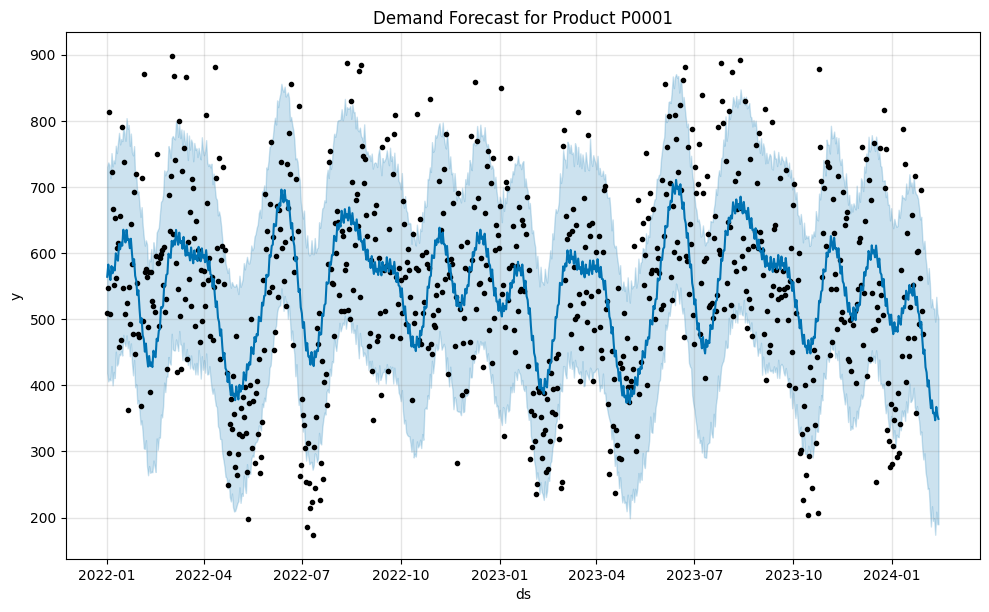

09:34:26 - cmdstanpy - INFO - Chain [1] start processing
09:34:26 - cmdstanpy - INFO - Chain [1] done processing


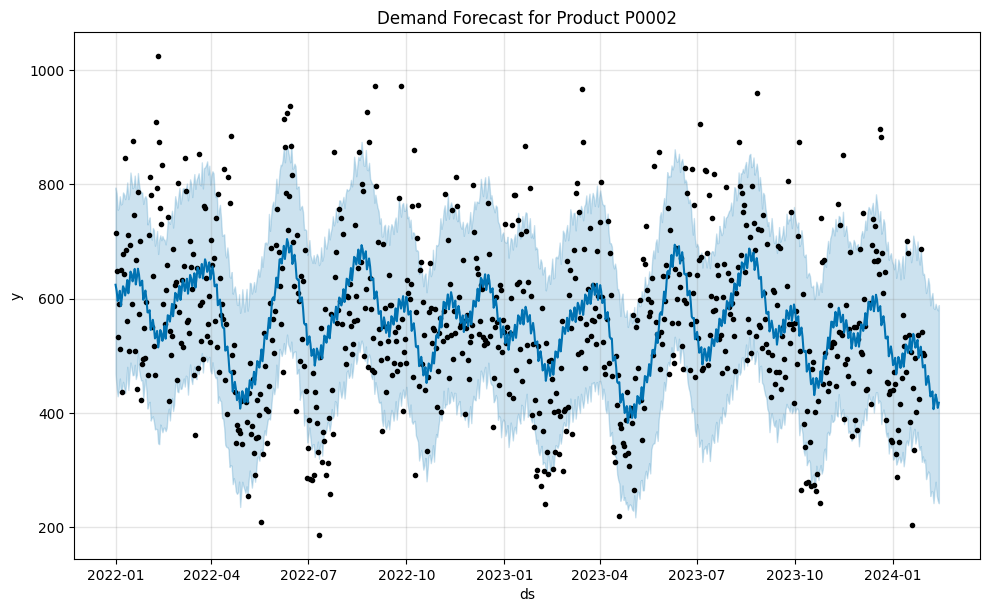

09:34:26 - cmdstanpy - INFO - Chain [1] start processing
09:34:26 - cmdstanpy - INFO - Chain [1] done processing


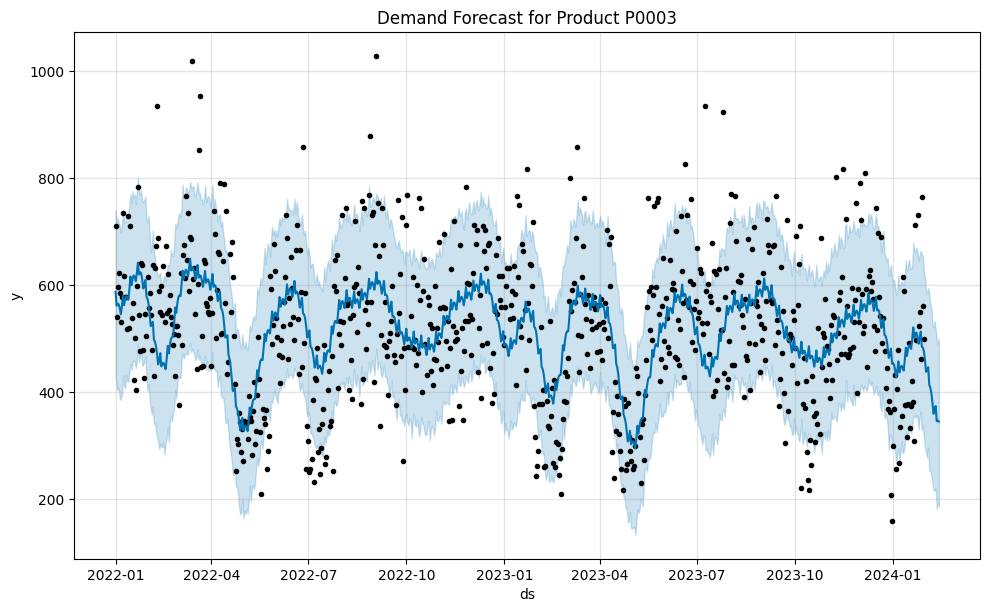

09:34:27 - cmdstanpy - INFO - Chain [1] start processing
09:34:27 - cmdstanpy - INFO - Chain [1] done processing
09:34:27 - cmdstanpy - INFO - Chain [1] start processing
09:34:27 - cmdstanpy - INFO - Chain [1] done processing
09:34:27 - cmdstanpy - INFO - Chain [1] start processing
09:34:27 - cmdstanpy - INFO - Chain [1] done processing
09:34:28 - cmdstanpy - INFO - Chain [1] start processing
09:34:28 - cmdstanpy - INFO - Chain [1] done processing
09:34:28 - cmdstanpy - INFO - Chain [1] start processing
09:34:28 - cmdstanpy - INFO - Chain [1] done processing
09:34:28 - cmdstanpy - INFO - Chain [1] start processing
09:34:28 - cmdstanpy - INFO - Chain [1] done processing
09:34:29 - cmdstanpy - INFO - Chain [1] start processing
09:34:29 - cmdstanpy - INFO - Chain [1] done processing
09:34:29 - cmdstanpy - INFO - Chain [1] start processing
09:34:29 - cmdstanpy - INFO - Chain [1] done processing
09:34:29 - cmdstanpy - INFO - Chain [1] start processing
09:34:29 - cmdstanpy - INFO - Chain [1]

In [6]:
# Loop over each product
for product in daily_demand['PRODUCT_ID'].unique():
    temp = daily_demand[daily_demand['PRODUCT_ID'] == product][['ds','y']]
    
    # Initialize Prophet
    model = Prophet(daily_seasonality=True, yearly_seasonality=True)
    model.fit(temp)
    
    # Create future dates
    future = model.make_future_dataframe(periods=forecast_period)
    
    # Predict demand
    forecast = model.predict(future)
    
    # Store forecast
    forecasts[product] = forecast[['ds','yhat','yhat_lower','yhat_upper']]
    
    # Optional: plot for first few products
    if product in daily_demand['PRODUCT_ID'].unique()[:3]:
        model.plot(forecast)
        plt.title(f'Demand Forecast for Product {product}')
        plt.show()

In [7]:
# Combine all product forecasts into one DataFrame
all_forecasts = pd.DataFrame()

for product, forecast in forecasts.items():
    temp = forecast.copy()
    temp['PRODUCT_ID'] = product  # add product column
    all_forecasts = pd.concat([all_forecasts, temp], ignore_index=True)

# Reorder columns
all_forecasts = all_forecasts[['PRODUCT_ID','ds','yhat','yhat_lower','yhat_upper']]

# Show first few rows
print(all_forecasts.head())

  PRODUCT_ID         ds        yhat  yhat_lower  yhat_upper
0      P0001 2022-01-01  564.028021  418.533585  730.349739
1      P0001 2022-01-02  582.515176  405.855959  737.009824
2      P0001 2022-01-03  567.884552  410.058883  733.026921
3      P0001 2022-01-04  559.216776  407.328477  712.979249
4      P0001 2022-01-05  580.217285  429.126040  751.065595


In [9]:
all_forecasts.to_csv('product_demand_forecast.csv', index=False)